**Insight 2: Job Satisfaction → Performance Rating**<br>
Target: PerformanceRating (multi-class: 1, 2, 3, 4)<br>
Model: Random Forest<br>
Goal: Predict employee performance rating using full dataset

In [3]:
import pandas as pd
import numpy as np
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestClassifier
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, confusion_matrix, classification_report
import matplotlib.pyplot as plt
import seaborn as sns

In [4]:
df = pd.read_csv("cleaned_employee_data.csv")

In [5]:
X = df.drop(columns=['PerformanceRating'])
y = df['PerformanceRating']

In [6]:
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

In [7]:
X_train, X_test, y_train, y_test = train_test_split(
    X_scaled, y, test_size=0.3, random_state=42, stratify=y
)

In [13]:
rf_model = RandomForestClassifier(n_estimators=100, random_state=42)
rf_model.fit(X_train, y_train)

RandomForestClassifier(random_state=42)

In [15]:
y_pred_rf = rf_model.predict(X_test)

Accuracy: 100.00%

Classification Report:
               precision    recall  f1-score   support

           3       1.00      1.00      1.00       373
           4       1.00      1.00      1.00        68

    accuracy                           1.00       441
   macro avg       1.00      1.00      1.00       441
weighted avg       1.00      1.00      1.00       441



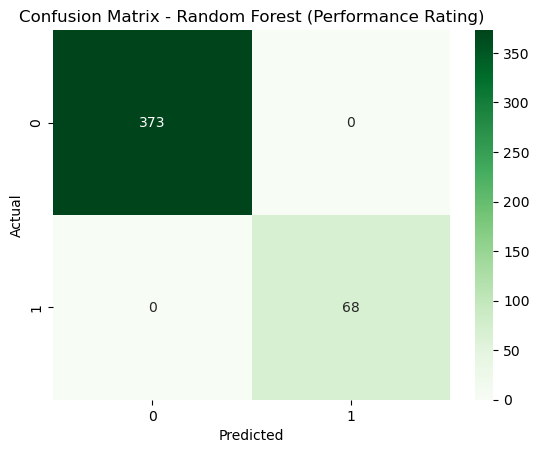

In [17]:
# Accuracy
print(f"Accuracy: {accuracy_score(y_test, y_pred_rf)*100:.2f}%")

# Classification Report
print("\nClassification Report:\n", classification_report(y_test, y_pred_rf, digits=2))

# Confusion Matrix
cm = confusion_matrix(y_test, y_pred_rf)
sns.heatmap(cm, annot=True, fmt='d', cmap='Greens')
plt.title("Confusion Matrix - Random Forest (Performance Rating)")
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.show()

In [19]:
precision = precision_score(y_test, y_pred_rf, average='macro') * 100
recall = recall_score(y_test, y_pred_rf, average='macro') * 100
f1 = f1_score(y_test, y_pred_rf, average='macro') * 100

print(f"Macro Precision: {precision:.2f}%")
print(f"Macro Recall: {recall:.2f}%")
print(f"Macro F1 Score: {f1:.2f}%")

Macro Precision: 100.00%
Macro Recall: 100.00%
Macro F1 Score: 100.00%


C:\Users\User\AppData\Local\Temp\ipykernel_16544\787337991.py:7: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=importances.head(10), x='Importance', y='Feature', palette='Greens_r')


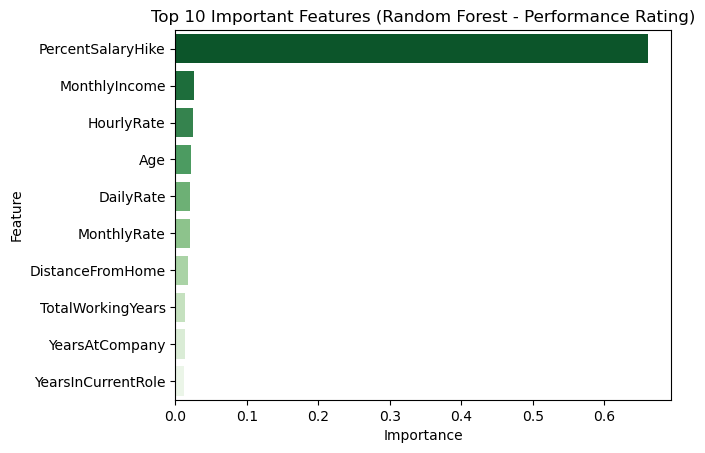

In [21]:
# Feature Importance
importances = pd.DataFrame({
    'Feature': df.drop(columns='PerformanceRating').columns,
    'Importance': rf_model.feature_importances_
}).sort_values(by='Importance', ascending=False)

sns.barplot(data=importances.head(10), x='Importance', y='Feature', palette='Greens_r')
plt.title("Top 10 Important Features (Random Forest - Performance Rating)")
plt.show()